<a href="https://colab.research.google.com/github/babiologa/Bioestat-stica/blob/main/tarefa06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bioestatística

##Barbara Aimy Baldin - 16856147
##Dante Gomes Soares de Morais - 16883610
##Marina de Oliveira Cappato - 16898499

# Relação entre comprimento corporal e massa corporal de artrópodes

## Regressão linear simples e correlação linear de Pearson

Neste trabalho, serão analisadas duas variáveis numéricas relacionadas às Ciências Biológicas: o comprimento corporal e a massa corporal viva de artrópodes.

O objetivo é verificar se existe uma relação linear entre essas duas variáveis utilizando a regressão linear simples e o coeficiente de correlação linear de Pearson.

##Apresentação do conjunto de dados

O conjunto de dados utilizado neste trabalho apresenta informações sobre artrópodes, incluindo medidas de comprimento corporal e massa corporal viva de diferentes indivíduos.

As duas variáveis selecionadas para a análise foram:

- Comprimento corporal (mm): representa o comprimento máximo do corpo do artrópode, sem considerar os apêndices.
- Massa corporal viva (mg): representa a massa do organismo vivo, medida em miligramas.

Neste estudo, o comprimento corporal será considerado a variável independente, representada por X, enquanto a massa corporal viva será considerada a variável dependente, representada por Y.

A análise busca verificar se artrópodes com maior comprimento corporal tendem a apresentar maior massa corporal.

## Fonte dos dados

Os dados utilizados foram obtidos do estudo:

Sohlström, E. H. et al. (2018). *Data from: Applying generalised allometric regressions to predict live body mass of tropical and temperate arthropods*. Dryad Digital Repository.

A base de dados está disponível no repositório Dryad, um repositório digital de dados científicos.

**Responsáveis pelos dados:** E. H. Sohlström e colaboradores.

**Instituição/plataforma responsável pela disponibilização:** Dryad Digital Repository.

**Link de acesso:**

https://datadryad.org/dataset/doi:10.5061/dryad.vk24fr1

**Data de acesso:** 25 de agosto de 2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

In [8]:
df = pd.read_excel("tarefa06.xlsx")
df.head()

,Ordem,Subordem,Familia,Massa corporal viva (mg),Comprimento corporal (mm),Largura do corpo (mm),Geographic Region,Grupos para a Tabela S1,Análise
0,coleoptera,NaN,carabidae,152.3,14.6,2026-08-06 00:00:00,temperate,Coleoptera (other),Main Analysis and Supporting Information
1,diptera,brachycera,lauxaniidae,4.15,4.9,2026-05-01 00:00:00,tropical,Diptera (Brachycera),Main Analysis and Supporting Information
2,coleoptera,polyphaga,staphylinidae,0.25,2.56,4.97,tropical,Coleoptera (Staphylinidae),Main Analysis and Supporting Information
3,araneae,labidognatha,araneidae,8.71,3.46,3.66,tropical,Araneae (webbuilding),Main Analysis and Supporting Information
4,araneae,labidognatha,araneidae,16.17,4.14,4.29,tropical,Araneae (webbuilding),Main Analysis and Supporting Information


In [9]:
df.columns

Index(['Ordem', 'Subordem', 'Familia', 'Massa corporal viva (mg)',
       'Comprimento corporal (mm)', 'Largura do corpo (mm)',
       'Geographic Region', 'Grupos para a Tabela S1', 'Análise'],
      dtype='object')

In [10]:
df = df[
    [

    "Comprimento corporal (mm)"
    ,"Massa corporal viva (mg)"
]
]

df= df.dropna()

df.head()

,Comprimento corporal (mm),Massa corporal viva (mg)
0,14.6,152.3
1,4.9,4.15
2,2.56,0.25
3,3.46,8.71
4,4.14,16.17


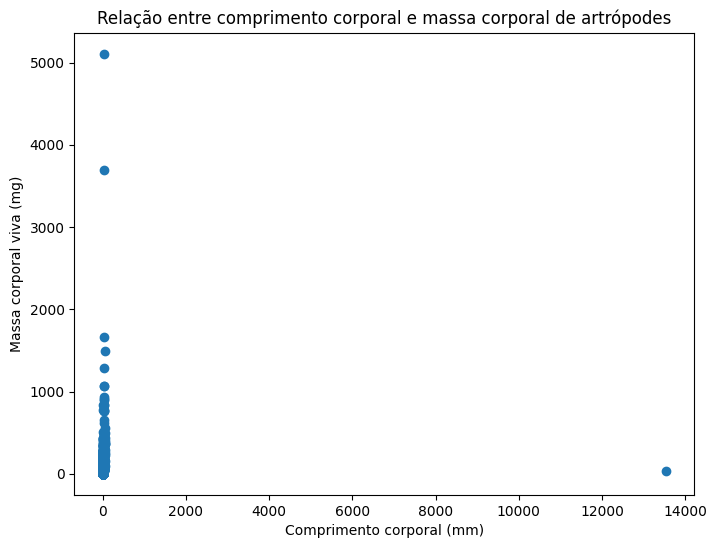

In [13]:

df['Comprimento corporal (mm)'] = pd.to_numeric(df['Comprimento corporal (mm)'], errors='coerce')
df['Massa corporal viva (mg)'] = pd.to_numeric(df['Massa corporal viva (mg)'], errors='coerce')


df = df.dropna(subset=['Comprimento corporal (mm)', 'Massa corporal viva (mg)'])

plt.figure(figsize=(8, 6))

plt.scatter(
    df['Comprimento corporal (mm)'],
    df['Massa corporal viva (mg)']
)

plt.title("Relação entre comprimento corporal e massa corporal de artrópodes")
plt.xlabel("Comprimento corporal (mm)")
plt.ylabel("Massa corporal viva (mg)")

plt.show()

## 3. Regressão linear simples

A regressão linear simples é uma técnica estatística utilizada para estudar a relação entre duas variáveis numéricas.

Ela permite estimar uma reta que representa a relação entre uma variável independente, representada por **X**, e uma variável dependente, representada por **Y**.

A equação geral da regressão linear simples é:

$$
Y = \beta_0 + \beta_1X
$$

Em que:

- $Y$ representa a variável dependente;
- $X$ representa a variável independente;
- $\beta_0$ representa o intercepto da reta;
- $\beta_1$ representa o coeficiente angular da reta.

Neste trabalho, a regressão será utilizada para estimar a relação entre o comprimento corporal dos artrópodes e sua massa corporal viva.

## 4. Estimação dos coeficientes da reta de regressão

A partir dos dados observados, serão estimados os dois coeficientes da reta de regressão linear simples:

- Intercepto: indica o valor estimado de Y quando X é igual a zero.
- Coeficiente angular: indica quanto a variável Y tende a variar, em média, para cada aumento de uma unidade na variável X.

In [15]:
X = df[["Comprimento corporal (mm)"]]

y = df["Massa corporal viva (mg)"]

modelo = LinearRegression()

modelo.fit(X, y)

intercepto = modelo.intercept_

coeficiente_angular = modelo.coef_[0]

print("Intercepto:", intercepto)

print("Coeficiente angular:", coeficiente_angular)

Intercepto: 31.28555697346759
Coeficiente angular: 0.010436511023140752


In [16]:
print(
    f"Equação da reta de regressão:\n"
    f"Massa corporal = {intercepto:.4f} + "
    f"({coeficiente_angular:.4f} × Comprimento corporal)"
)

Equação da reta de regressão:
Massa corporal = 31.2856 + (0.0104 × Comprimento corporal)


##Interpretação dos coeficientes

O intercepto representa a massa corporal estimada para um artrópode com comprimento corporal igual a zero milímetros. Como um artrópode real não possui comprimento corporal igual a zero, esse valor possui principalmente uma interpretação matemática dentro do modelo.

O coeficiente angular representa a variação estimada na massa corporal viva para cada aumento de um milímetro no comprimento corporal.

Assim, quando o coeficiente angular for positivo, isso indica que, de acordo com o modelo estimado, artrópodes com maior comprimento corporal tendem a apresentar maior massa corporal.

##Reta de regressão no gráfico de dispersão

A reta de regressão será adicionada ao gráfico de dispersão para representar visualmente a relação estimada entre o comprimento corporal e a massa corporal dos artrópodes.

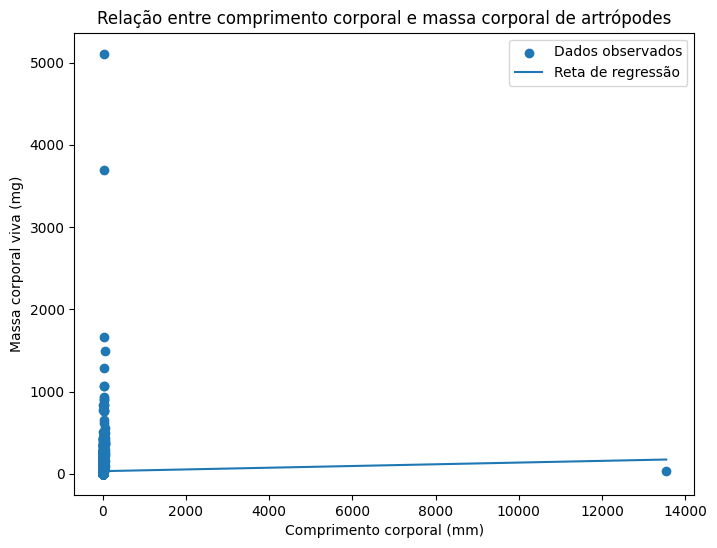

In [18]:
x_ordenado = np.sort(
    df["Comprimento corporal (mm)"].values
)

x_ordenado_dataframe = pd.DataFrame(
    x_ordenado,
    columns=["Comprimento corporal (mm)"]
)

y_estimado = modelo.predict(x_ordenado_dataframe)

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Comprimento corporal (mm)"],
    df["Massa corporal viva (mg)"],
    label="Dados observados"
)

plt.plot(
    x_ordenado,
    y_estimado,
    label="Reta de regressão"
)

plt.title(
    "Relação entre comprimento corporal e massa corporal de artrópodes"
)

plt.xlabel("Comprimento corporal (mm)")

plt.ylabel("Massa corporal viva (mg)")

plt.legend()

plt.show()

##Correlação linear de Pearson

O coeficiente de correlação linear de Pearson é uma medida estatística utilizada para avaliar a direção e a intensidade de uma relação linear entre duas variáveis numéricas.

Esse coeficiente é representado pela letra **r** e pode variar entre -1 e 1.

A fórmula do coeficiente de correlação de Pearson é:

$$
r =
\frac{
\sum_{i=1}^{n}
(x_i-\bar{x})(y_i-\bar{y})
}
{
\sqrt{
\sum_{i=1}^{n}(x_i-\bar{x})^2
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
}
$$

De forma geral:

- Valores próximos de **1** indicam uma forte associação linear positiva;
- Valores próximos de **-1** indicam uma forte associação linear negativa;
- Valores próximos de **0** indicam pouca ou nenhuma associação linear.

In [20]:
correlacao, p_valor = pearsonr(
    df["Comprimento corporal (mm)"],
    df["Massa corporal viva (mg)"]
)

print("Coeficiente de correlação de Pearson:", correlacao)

print("Valor de p:", p_valor)

Coeficiente de correlação de Pearson: 0.01690010977007992
Valor de p: 0.25449790281295004


##Interpretação do coeficiente de correlação

O valor do coeficiente de correlação de Pearson calculado representa a intensidade e a direção da relação linear entre o comprimento corporal e a massa corporal dos artrópodes.

Um valor positivo indica que, de forma geral, valores maiores de comprimento corporal estão associados a valores maiores de massa corporal.

Quanto mais próximo o coeficiente estiver de 1, mais forte será a associação linear positiva observada entre as variáveis.

##Direção da correlação observada

A correlação observada entre as variáveis pode ser interpretada de acordo com o sinal do coeficiente de Pearson.

- Correlação positiva: valores maiores de uma variável tendem a estar associados a valores maiores da outra variável.
- Correlação negativa: valores maiores de uma variável tendem a estar associados a valores menores da outra variável.
- Correlação próxima de zero: não há evidência de uma associação linear relevante entre as variáveis.

Neste estudo, espera-se uma correlação positiva entre o comprimento corporal e a massa corporal, pois artrópodes maiores tendem a apresentar maior massa.

##Correlação próxima de zero e relações não lineares

Um coeficiente de correlação igual ou próximo de zero indica ausência ou pouca evidência de uma relação linear entre as duas variáveis.

Entretanto, isso não significa necessariamente que não exista qualquer relação entre elas.

Duas variáveis podem apresentar uma relação não linear, como uma relação curva, e ainda assim possuir um coeficiente de correlação de Pearson baixo.

Por isso, além de calcular o coeficiente de Pearson, é importante observar o gráfico de dispersão para compreender melhor o comportamento da relação entre as variáveis.

##Conclusão

A análise realizada permitiu investigar a relação entre o comprimento corporal e a massa corporal viva de artrópodes.

A regressão linear simples permitiu estimar uma reta que descreve a relação entre as duas variáveis, enquanto o coeficiente de correlação de Pearson permitiu avaliar a direção e a intensidade da associação linear observada.

De acordo com os resultados obtidos, espera-se observar uma relação positiva entre o comprimento corporal e a massa corporal, indicando que artrópodes com maior comprimento tendem, de modo geral, a apresentar maior massa.

Dessa forma, a regressão linear simples e a correlação de Pearson são ferramentas importantes para auxiliar na interpretação de dados biológicos, permitindo descrever e quantificar relações entre variáveis numéricas.